# 2026-10-04 · The learning time $T^*(L)$ in the effective model

In the $d=\infty$ sweep (`L_sweep_reduced`, $V=128$, $K=25$, $\beta=0.25$, $\eta_0=3500$, three seeds) $T^*$ does not grow with $L$. It even falls from $L=64$ to $L\approx256$. Which variant of the ansatz reproduces that, and is anything outside the ansatz needed?

Three sources of $T^*$ for every run (same seed, same initial order parameters):
- **real**: the run itself;
- **control**: the same training from the ansatz projection of the same initial draw (`model_args.ansatz_init=true`): the same order parameters, without the spread of the entries around them (`scripts/L_sweep_controls.py`);
- **spread QG / spread M**: the same, but keeping the drawn $\bm Q,\bm\Gamma$ (resp. $\bm M$) with their spread (`model_args.ansatz_keep_spread`);
- **flow**: the gradient flow of the effective loss (`method="mean"`) from the same order parameters, with rates $\alpha_{lr}/n_i$, exact at $d=\infty$ on the ansatz (`scripts/L_sweep_flows.py`), for three nested variants: **signal** ($M^{on},Q^{on},\Gamma^{on}$), **trigger** ($+\,Q^T,\Gamma^T$) and **extended** ($+\,M^{off}$).

**Learning time.** Top-1 accuracy is useless without the spread: the argmax only sees the ordering of the logits, so a deterministic model can be 98% "accurate" at loss $\log V$. $T^*$ is therefore the step where the loss has gone a fraction $f=0.2$ of the way from $\log V$ to the manuscript's $\mathcal L^\infty$ (`asymptotic_loss`, `learning_time`).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import json
import math
import pickle

from icl import RunData, asymptotic_loss, learning_time

# Save figure as svg
# path = Path('../../presentation/public/fig/')
path = Path('./')
# Make sure the directory exists
path.mkdir(parents=True, exist_ok=True)

# Plot Configs

In [2]:
"""
Script to set up the configurations for the plots.
"""
# Define font sizes
FONTSIZES = {
    'xxs': 4,
    'xs': 6,
    's': 8,
    'm': 10,
    'l': 12,
    'xl': 14,
    'xxl': 16
}

double_w = 7.2  # Width for double column
single_w = 3.5  # Width for single column

def set_font_sizes(conf='normal', factor=1, sizes=None):
    """
    Set font sizes for plots.
    """
    keys = ['font.size', 'axes.labelsize', 'axes.titlesize',
            'xtick.labelsize', 'ytick.labelsize',
            'legend.fontsize', 'figure.titlesize']
    
    if conf == 'normal':
        sizes = ['m', 'm', 'm', 's', 's', 's', 'l']
    elif conf == 'equal':
        sizes = ['m', 'm', 'm', 'm', 'm', 'm', 'm']
    elif conf == 'tight':
        sizes = ['s', 'm', 'm', 'xs', 'xs', 'xs', 'm']
    elif conf == 'custom':
        if sizes is None:
            raise ValueError("Must specify list of sizes (e.g., ['m', 'm', 'm', 's', 's', 's', 'l'])")
    
    for size, key in zip(sizes, keys):
        plt.rcParams[key] = FONTSIZES[size] * factor


def apply_general_styles():
    """
    Apply general plot styles.
    """
    plt.rcParams.update({
        'mathtext.fontset': 'cm',
        'font.family': 'STIXGeneral',
        'axes.spines.top': False,
        'axes.spines.right': False,
        'figure.dpi': 150,
        'text.usetex': False,
        'text.latex.preamble': r'\usepackage{amsmath,amssymb}'
    })


def create_fig(nrows=1,ncols=1,size='single',w=1.0,h=0.5,layout='constrained',sharex=True,sharey=None,w_ratios=None,h_ratios=None):
    width = single_w if size=='single' else double_w
    figsize = (w*width,h*width)
    fig , axes = plt.subplots(nrows=nrows,ncols=ncols,figsize=figsize,layout=layout,sharex=sharex,sharey=sharey,gridspec_kw={'width_ratios': w_ratios, 'height_ratios': h_ratios})
    return fig , axes

apply_general_styles()
set_font_sizes(conf='tight')

# Code

## 1. The runs and the criterion

Two real runs (seed 3, $L=64,128$) stopped on the accuracy before their loss had moved; they were rerun with the same seed and a loss stop (`L_sweep_reduced_loss_stop`) and are read from there. The controls stop at $f=0.5$.

For the real runs the criterion agrees with the accuracy one: $T^*_{f=0.2}$ is within a few percent of $T^*_{\rm acc}$ (first step with accuracy $\ge0.75$).

In [3]:
BASE, FRACTION = "../data", 0.2
SOURCES = ["real", "control", "signal", "trigger", "extended", "spread QG", "spread M"]   # fixed order: colors C0..C6
SPREAD = {"spread QG": "L_sweep_reduced_spread_QG", "spread M": "L_sweep_reduced_spread_M"}
RERUN = {"run_041": "run_001", "run_042": "run_002"}            # L_sweep_reduced -> L_sweep_reduced_loss_stop


def loss_series(run):
    return run.metrics["loss"].dropna()


def runs_by_L_and_seed(experiment):
    found = {}
    for run_dir in sorted(Path(BASE, experiment).glob("run_*")):
        run = RunData(experiment, run_dir.name, base_dir=BASE)
        if run.config.model_args.infinite_d:
            found[(run.config.model_args.seq_len, run.config.extra_args.seed)] = run
    return found


real = runs_by_L_and_seed("L_sweep_reduced")
control = runs_by_L_and_seed("L_sweep_reduced_ansatz_init")
spread = {source: runs_by_L_and_seed(experiment) for source, experiment in SPREAD.items()}
V, K = 128, 25
rows = []
for (L, seed), run in real.items():
    rerun = RERUN.get(run.run_id)
    curve = loss_series(RunData("L_sweep_reduced_loss_stop", rerun, base_dir=BASE) if rerun else run)
    accuracy = run.metrics["top1_accuracy"].dropna()
    rows.append({"L": L, "seed": seed, "run": run.run_id,
                 "T_acc": accuracy.index[np.argmax(accuracy.to_numpy() >= 0.75)],
                 "real": learning_time(curve, V, L, K, FRACTION),
                 "control": learning_time(loss_series(control[(L, seed)]), V, L, K, FRACTION),
                 **{source: learning_time(loss_series(runs[(L, seed)]), V, L, K, FRACTION)
                    for source, runs in spread.items()}})
times = pd.DataFrame(rows)
flow_times = pd.read_csv(Path(BASE, "effective_L_sweep/learning_times.csv"))
times = times.merge(flow_times.pivot(index="run", columns="variant", values="T_star"), left_on="run", right_index=True)
times = times.sort_values(["seed", "L"]).set_index(["seed", "L"])
times.round(0)

run  T_acc    real  control  spread QG  spread M  extended  \
seed L                                                                      
1    64    run_011   3642  3625.0   1234.0     4356.0    1137.0    1323.0   
     128   run_012   1967  1944.0    594.0     2466.0     651.0     677.0   
     256   run_013   1217  1185.0    619.0     1627.0     708.0     692.0   
     512   run_014   1721  1683.0   1088.0     4523.0    1466.0    1293.0   
     1024  run_015   1252  1219.0   1106.0     3032.0     953.0    1206.0   
2    64    run_026    634   619.0    311.0      741.0     268.0     368.0   
     128   run_027    578   556.0    439.0      551.0     476.0     553.0   
     256   run_028    435   419.0    334.0      384.0     373.0     362.0   
     512   run_029    467   422.0    365.0      393.0     394.0     388.0   
     1024  run_030    973   936.0   1094.0     1513.0     761.0    1165.0   
3    64    run_041   6040  6051.0    884.0     5653.0     781.0     961.0   
     128   run_042   3601  3609.0   1847.0     4421.0    1300.0    2254.0   
     256   run_043   4450  4418.0   1427.0     4029.0    1212.0    1644.0   
     512   run_044   4277  4256.0   1605.0    16732.0    1303.0    1819.0   
     1024  run_045   1982  1950.0   1558.0     4703.0    1382.0    1747.0   

            signal  trigger  
seed L                       
1    64     1380.0   1331.0  
     128    1191.0   1174.0  
     256    1981.0   1943.0  
     512    3117.0   3122.0  
     1024  13950.0  12386.0  
2    64      850.0    625.0  
     128    2221.0   1237.0  
     256    6355.0   3966.0  
     512   10119.0   4989.0  
     1024  13160.0  14866.0  
3    64      962.0    961.0  
     128    5653.0   4371.0  
     256    4031.0   4048.0  
     512    6181.0   5582.0  
     1024   4511.0   4490.0

## 2. $T^*(L)$

One panel per seed (the seed-to-seed spread is large: compare within a seed, or medians). First the ansatz variants without spread, then which spread brings back the real $T^*$.

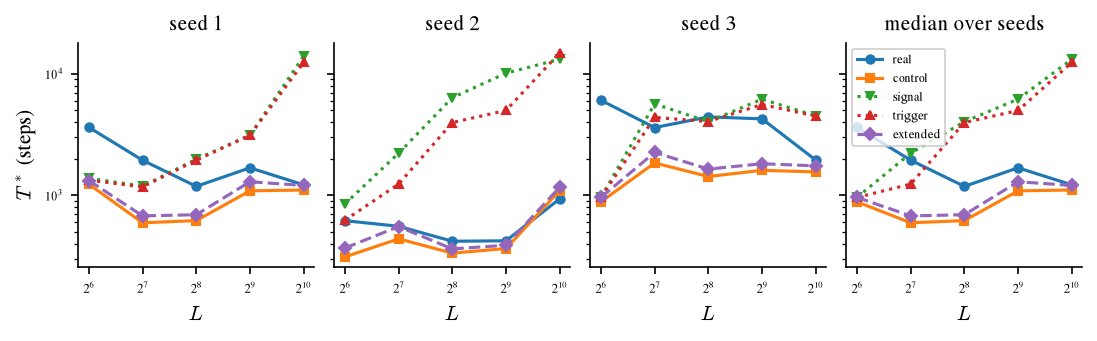

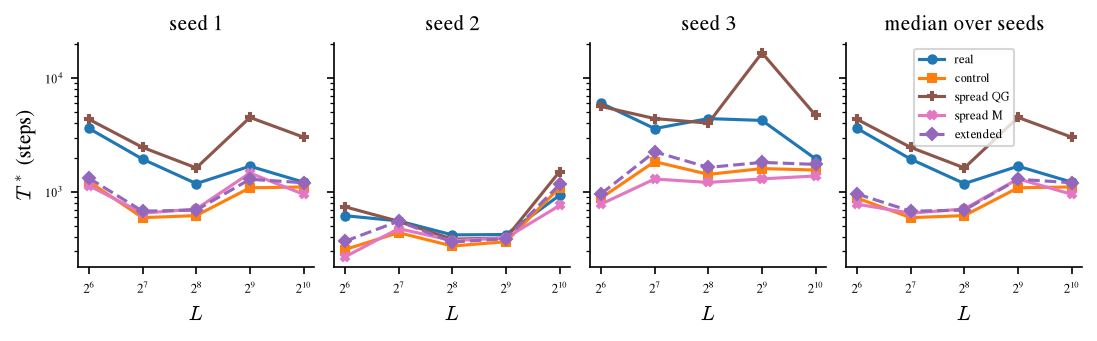

In [4]:
markers = {"real": "o", "control": "s", "signal": "v", "trigger": "^", "extended": "D", "spread QG": "P", "spread M": "X"}
styles = {"real": "-", "control": "-", "signal": ":", "trigger": ":", "extended": "--", "spread QG": "-", "spread M": "-"}
panels = [(f"seed {seed}", times.xs(seed, level="seed")) for seed in (1, 2, 3)]
panels.append(("median over seeds", times.groupby(level="L")[SOURCES].median()))


def plot_times(sources):
    fig, axes = create_fig(ncols=4, size='double', h=0.3, sharex=True, sharey=True)
    for ax, (title, table) in zip(axes, panels):
        for source in sources:
            color = SOURCES.index(source)
            ax.plot(table.index, table[source], styles[source], marker=markers[source], ms=4, color=f"C{color}", label=source)
        ax.set_xscale("log", base=2); ax.set_yscale("log")
        ax.set_title(title); ax.set_xlabel(r"$L$")
    axes[0].set_ylabel(r"$T^*$ (steps)")
    axes[-1].legend(fontsize=6)


plot_times(["real", "control", "signal", "trigger", "extended"])
plt.show()
plot_times(["real", "control", "spread QG", "spread M", "extended"])
plt.show()

## 3. The loss curves

Progress $(\log V-\mathcal L)/(\log V-\mathcal L^\infty)$ against the step, for every source except the signal and trigger flows, for one seed. The dotted line is the criterion $f=0.2$.

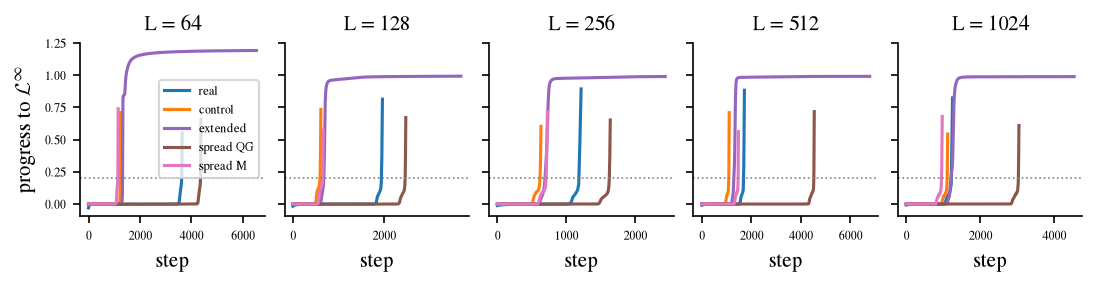

In [5]:
flows = pickle.loads(Path(BASE, "effective_L_sweep/flows.pkl").read_bytes())
SEED = 1


def progress(loss, L):
    return (math.log(V) - loss) / (math.log(V) - asymptotic_loss(V, L, K))


Ls = sorted(L for L, seed in real if seed == SEED)
fig, axes = create_fig(ncols=len(Ls), size='double', h=0.25, sharex=False, sharey=True)
for ax, L in zip(axes, Ls):
    run = real[(L, SEED)]
    rerun = RERUN.get(run.run_id)
    curves = {"real": loss_series(RunData("L_sweep_reduced_loss_stop", rerun, base_dir=BASE) if rerun else run),
              "control": loss_series(control[(L, SEED)]),
              "extended": flows[(run.run_id, "extended")]["loss"],
              **{source: loss_series(runs[(L, SEED)]) for source, runs in spread.items()}}
    horizon = 1.5 * max(times.loc[(SEED, L), list(curves)])
    for source, curve in curves.items():
        curve = curve[curve.index <= horizon]
        ax.plot(curve.index, progress(curve, L), color=f"C{SOURCES.index(source)}", label=source)
    ax.axhline(FRACTION, ls=":", lw=0.8, color="gray")
    ax.set_title(f"L = {L}"); ax.set_xlabel("step")
axes[0].set_ylabel("progress to $\\mathcal{L}^\\infty$")
axes[0].legend(fontsize=6)
plt.show()

## 4. The order parameters: control vs extended flow

If the ansatz is right, the control (real training, no spread) and the extended flow follow the same trajectory. Logged order parameters of the control against the flow, for one run.

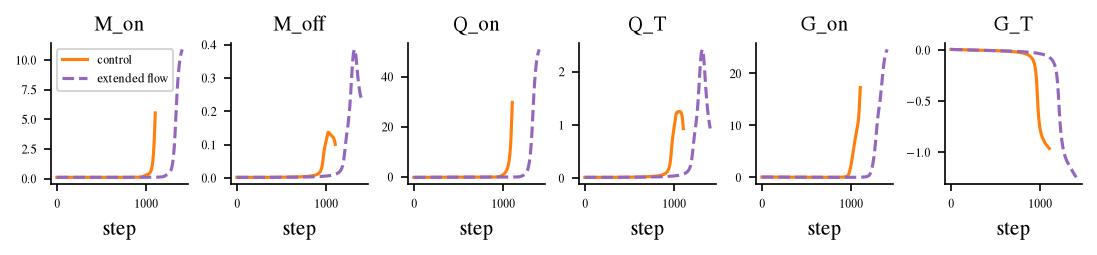

In [6]:
L = 512
run_id = real[(L, SEED)].run_id
flow, logged = flows[(run_id, "extended")], control[(L, SEED)].metrics
names = ["M_on", "M_off", "Q_on", "Q_T", "G_on", "G_T"]
horizon = 1.3 * times.loc[(SEED, L), "control"]
fig, axes = create_fig(ncols=len(names), size='double', h=0.22, sharex=True, sharey=False)
for ax, name in zip(axes, names):
    ax.plot(logged.index[logged.index <= horizon], logged[name][logged.index <= horizon], color="C1", label="control")
    ax.plot(flow.index[flow.index <= horizon], flow[name][flow.index <= horizon], "--", color="C4", label="extended flow")
    ax.set_title(name); ax.set_xlabel("step")
axes[0].legend(fontsize=6)
plt.show()

## 5. Weaker spread: $\sigma_0=0.5$

The spread enters the loss through the random part of the initial logits, about $\beta\sigma_0^4$ ($q\propto\sigma_0^2$, $m,g\propto\sigma_0$). The same sweep at $\sigma_0=0.5$ (same seeds, so the same draws scaled; random logit part $16\times$ weaker): if the spread is what slows small $L$ down, the real runs should now follow the control and the extended flow at every $L$. The last panel is the slowdown real / control for both $\sigma_0$.

real  control  extended
seed L                              
1    64    3969.0   4961.0    3683.0
     128   2568.0   2185.0    1600.0
     256   2833.0   2240.0    1620.0
2    64    1038.0   1151.0    1001.0
     128   1570.0   1588.0    2685.0
     256   1153.0   1106.0     872.0
3    64    6053.0   3570.0    2668.0
     128   9235.0   7195.0    6342.0
     256  11458.0   5465.0    3494.0

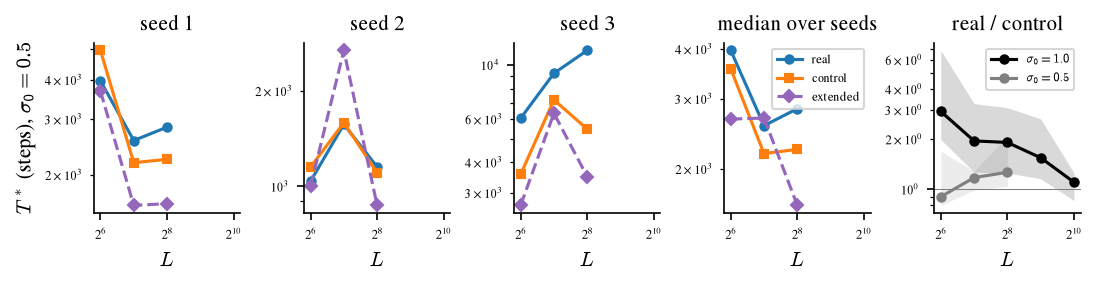

In [7]:
PREFIX = "L_sweep_reduced_sigma0.5"
real_05, control_05 = runs_by_L_and_seed(f"{PREFIX}_loss_stop"), runs_by_L_and_seed(f"{PREFIX}_ansatz_init")
flow_05 = pd.read_csv(Path(BASE, f"effective_{PREFIX}_loss_stop/learning_times.csv"))
flow_05 = flow_05[flow_05["variant"] == "extended"].set_index(["seed", "L"])["T_star"]
times_05 = pd.DataFrame([{"seed": seed, "L": L,
                          "real": learning_time(loss_series(run), V, L, K, FRACTION),
                          "control": learning_time(loss_series(control_05[(L, seed)]), V, L, K, FRACTION),
                          "extended": flow_05.loc[(seed, L)]}
                         for (L, seed), run in real_05.items()]).sort_values(["seed", "L"]).set_index(["seed", "L"])
display(times_05.round(0))

fig, axes = create_fig(ncols=5, size='double', h=0.25, sharex=True, sharey=False)
panels_05 = [(f"seed {seed}", times_05.xs(seed, level="seed")) for seed in (1, 2, 3)]
panels_05.append(("median over seeds", times_05.groupby(level="L").median()))
for ax, (title, table) in zip(axes, panels_05):
    for source in ("real", "control", "extended"):
        ax.plot(table.index, table[source], styles[source], marker=markers[source], ms=4,
                color=f"C{SOURCES.index(source)}", label=source)
    ax.set_xscale("log", base=2); ax.set_yscale("log"); ax.set_title(title); ax.set_xlabel(r"$L$")
axes[0].set_ylabel(r"$T^*$ (steps), $\sigma_0=0.5$")
axes[3].legend(fontsize=6)
for sigma, table, color in ((1.0, times, "k"), (0.5, times_05, "gray")):
    ratio = (table["real"] / table["control"]).groupby(level="L")
    axes[4].plot(ratio.median().index, ratio.median(), "o-", color=color, ms=4, label=fr"$\sigma_0={sigma}$")
    axes[4].fill_between(ratio.min().index, ratio.min(), ratio.max(), color=color, alpha=0.15, lw=0)
axes[4].axhline(1, lw=0.5, color="gray"); axes[4].set_yscale("log")
axes[4].set_title("real / control"); axes[4].set_xlabel(r"$L$"); axes[4].legend(fontsize=6)
plt.show()

## Reading

- **The extended ansatz is a good reduced model of the spread-free dynamics.** In all 15 runs the extended flow lands within 3–25% of the control, and it is always a little slower (median about 10%). The six order-parameter trajectories agree too (section 4).
- **$M^{off}$, $Q^T$ and $\Gamma^T$ are all needed.** Without them $T^*$ grows roughly like $L$. Dropping any one of the three already brings that back (medians at $L=1024$: about 5000 steps without $\Gamma^T$, about 5000 without $Q^T$, about 12400 without $M^{off}$, against about 1200 for the full extended ansatz). The escape at large $L$ is the bulk circuit $M^{off}Q^T\Gamma^T$ (2026-09-28 diagnosis, §5).
- **The slowdown at small $L$ is the spread of $\bm Q,\bm\Gamma$.**
  - The spread of $\bm M$ alone changes nothing: spread M ≈ control at every $L$.
  - The spread of $\bm Q,\bm\Gamma$ alone reproduces the real $T^*$ at $L\le256$ (seed 1: 4356 / 2466 / 1627 against the real 3625 / 1944 / 1185).
- **But the spread of $\bm Q,\bm\Gamma$ alone is too slow at large $L$** (seed 3, $L=512$: 16732 against the real 4256). The reason is the spread of $\bm M$: it is what removes the spread of $\bm Q,\bm\Gamma$. The curvature on $q,g$ is $\propto\langle m^2\rangle$, and it does not depend on $L$. At the last step, the off-diagonal std of $\bm Q$ / $\bm\Gamma$ is:

  | $L$ | real | spread QG |
  |---|---|---|
  | 512 | 0.40 / 0.47 | 0.90 / 0.61 |
  | 1024 | 0.45 / 0.48 | 0.99 / 0.70 |

  The std of the bulk of $\bm M$ stays at about 1 at large $L$, where its own curvature $\propto1/L^2$ is weak. At $L=64$ it has dropped to about 0.5.
- **Simplest ansatz that should explain $T^*(L)$:** the six means of the extended ansatz plus three spreads, $\sigma_q^2,\sigma_g^2$ and the spread of the bulk of $\bm M$, coupled through the curvature:
  - $\sigma_q^2\sigma_g^2$ slows the means of $\bm M$ with strength $\propto1/L^2$;
  - $\sigma_m^2$ removes $\sigma_q^2,\sigma_g^2$ at a rate independent of $L$;
  - $\sigma_q^2\sigma_g^2$ removes $\sigma_m^2$ with strength $\propto1/L^2$.

  This is inferred from the controls, not yet integrated as an effective model.
- **Weaker spread, $\sigma_0=0.5$** ($L\le256$; the random logit part $\propto\beta\sigma_0^4$ is $16\times$ weaker; section 5). The real / control slowdown falls from medians of 2.9, 2.0, 1.9 at $L=64,128,256$ to 0.90, 1.18, 1.26. So the small-$L$ slowdown shrinks with the spread, as expected if it is a finite-spread effect. It does not disappear, though: seed 3 keeps 1.7, 1.3, 2.1. At this $\sigma_0$ the extended flow is also less accurate against the control (−35% to +70%), because the initial order parameters are small and the escape spends long near 0, where minibatch noise matters.